In [8]:
# Basic Libraries
import os
import math
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing
import librosa
import librosa.display
import IPython.display as ipd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, concatenate
from tensorflow.keras.utils import to_categorical

# Optional (if used later in notebook)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [9]:
data_path = "Heartbeat_Sound"
print(os.listdir(data_path))

['artifact', 'extrahls', 'extrastole', 'murmur', 'normal', 'unlabel']


In [10]:

tarin_data      = data_path 
unlabel_data    = data_path  + "/unlabel/"

normal_data     = tarin_data + '/normal/'
murmur_data     = tarin_data + '/murmur/'
extrastole_data = tarin_data + '/extrastole/'
artifact_data   = tarin_data + '/artifact/'
extrahls_data   = tarin_data + "/extrahls/"




In [11]:
print("Normal files:", len(os.listdir(normal_data))) 
print("Murmur files:",len(os.listdir(murmur_data))) 
print("Extrastole files", len(os.listdir(extrastole_data))) 
print("Artifact files:",len(os.listdir(artifact_data))) 
print("Extrahls files:",len(os.listdir(extrahls_data))) 
print("Unlabel files : " , len(os.listdir(unlabel_data)))


print('TOTAL TRAIN SOUNDS:', len(os.listdir(normal_data)) 
                              + len(os.listdir(murmur_data))
                              + len(os.listdir(extrastole_data))
                              + len(os.listdir(artifact_data))
                              + len(os.listdir(extrahls_data))
                              + len(os.listdir(unlabel_data)))

Normal files: 351
Murmur files: 129
Extrastole files 46
Artifact files: 40
Extrahls files: 19
Unlabel files :  247
TOTAL TRAIN SOUNDS: 832


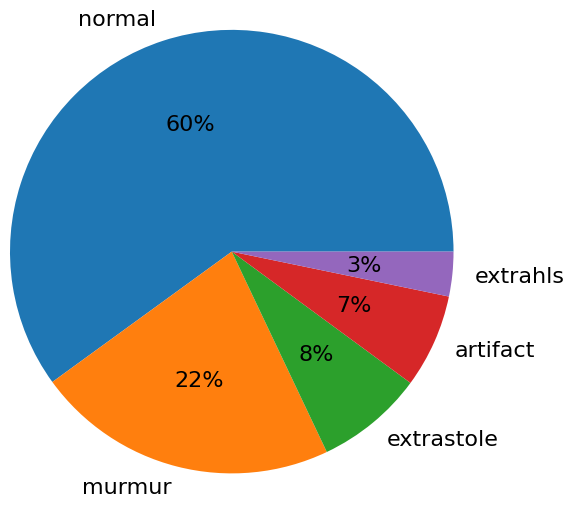

In [12]:
x = np.array([len(os.listdir(normal_data)),
              len(os.listdir(murmur_data)),
              len(os.listdir(extrastole_data)),
              len(os.listdir(artifact_data)),
              len(os.listdir(extrahls_data))])
labels = ['normal', 'murmur', 'extrastole', 'artifact', 'extrahls']
plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
plt.show()

In [13]:
 # Listen to rondom audio from specific class
def random_sound (audio_class):
    random_sound = np.random.randint(0,len(os.listdir(audio_class))) 
    sound = os.listdir(audio_class)[random_sound]
    sound = os.path.join(audio_class, sound)
    sound,sample_rate = librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

In [14]:
# show waveform of audio from dataset 
# X axis, represents time.
# Y-axis measures displacement of air molecules.
# This is where amplitude comes in. It measures how much a molecule is displaced from its resting position.  
def show_audio_waveform(audio_sample):
    plt.figure(figsize=(20,5))
    librosa.display.waveshow(audio_sample, sr = 22050)
#     plt.title("Sound")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

In [15]:

# show spectrum of audio from dataset 
def show_audio_spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)
    magnitude_normal = np.abs(fft_normal)
    freq_normal = np.linspace(0,sample_rate, len(magnitude_normal)) 
    half_freq = freq_normal[:int(len(freq_normal)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title("Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

In [16]:

# show specrogram of audio from dataset 
# the output is an image that represents a sound. 
# X-axis is for time, y-axis is for frequency and the color is for intensity
def show_spectrogram (audio_sample):    
    # STFT -> spectrogram
    hop_length = 512 # in num. of samples
    n_fft = 2048 # window in num. of samples
    sample_rate = 22050

    # calculate duration hop length and window in seconds
    hop_length_duration = float(hop_length)/sample_rate
    n_fft_duration = float(n_fft)/sample_rate

    print("STFT hop length duration is: {}s".format(hop_length_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    # perform stft
    stft_normal = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)

    # calculate abs values on complex numbers to get magnitude
    spectrogram = np.abs(stft_normal)
    log_spectrogram = librosa.amplitude_to_db(spectrogram)

    # display spectrogram
    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    #plt.set_cmap("YlOrBr")
    plt.title("Spectrogram")

In [17]:

# extract 52 MFCCs
def show_mfcc_features(audio_sample):

    hop_length = 512
    n_fft = 2048
    sample_rate = 22050

    MFCCs = librosa.feature.mfcc(
        y=audio_sample,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mfcc=52
    )

    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCs, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCs")
    plt.show()

#### 1. Normal
Most normal heart rates at rest will be between about 60 and 100 beats (‘lub dub’s) per minute.


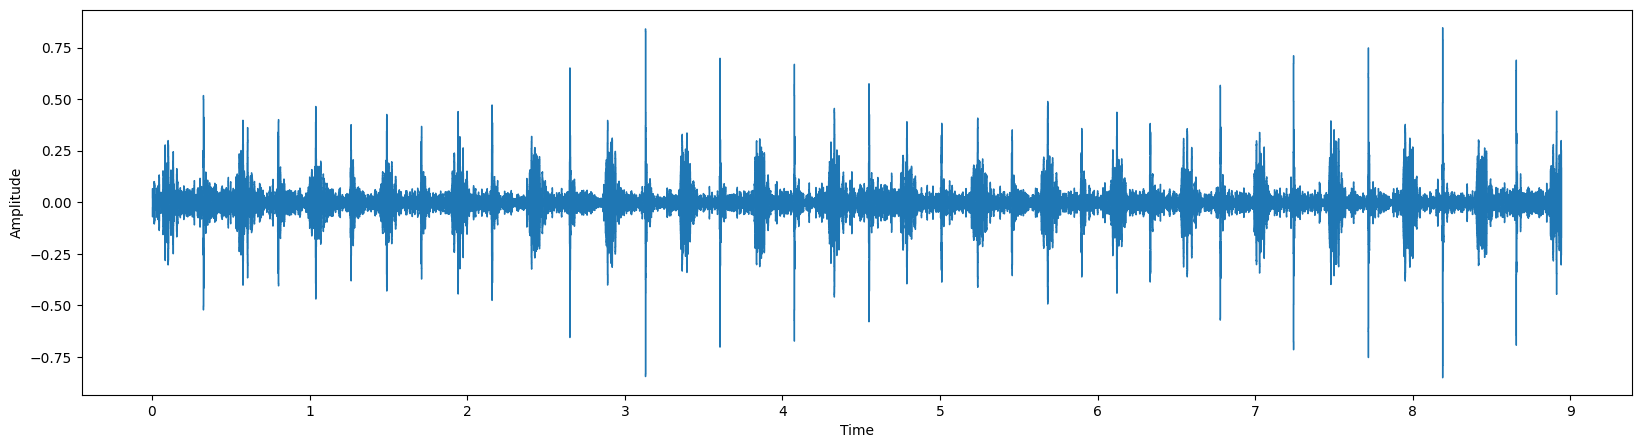

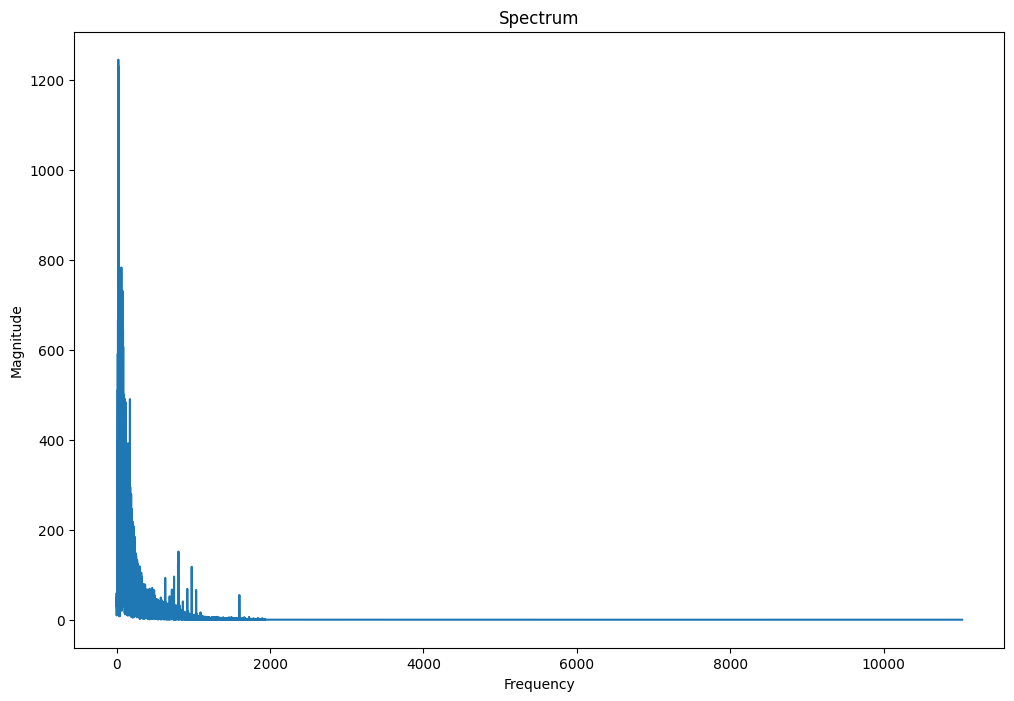

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


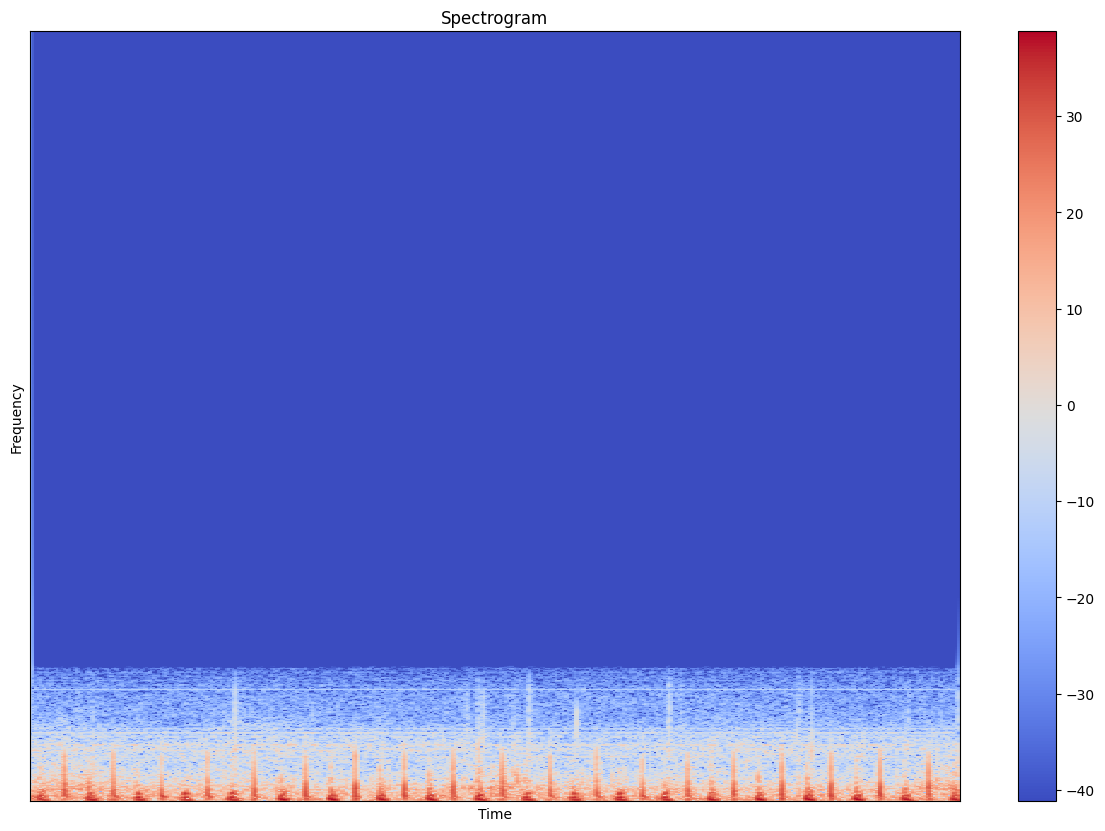

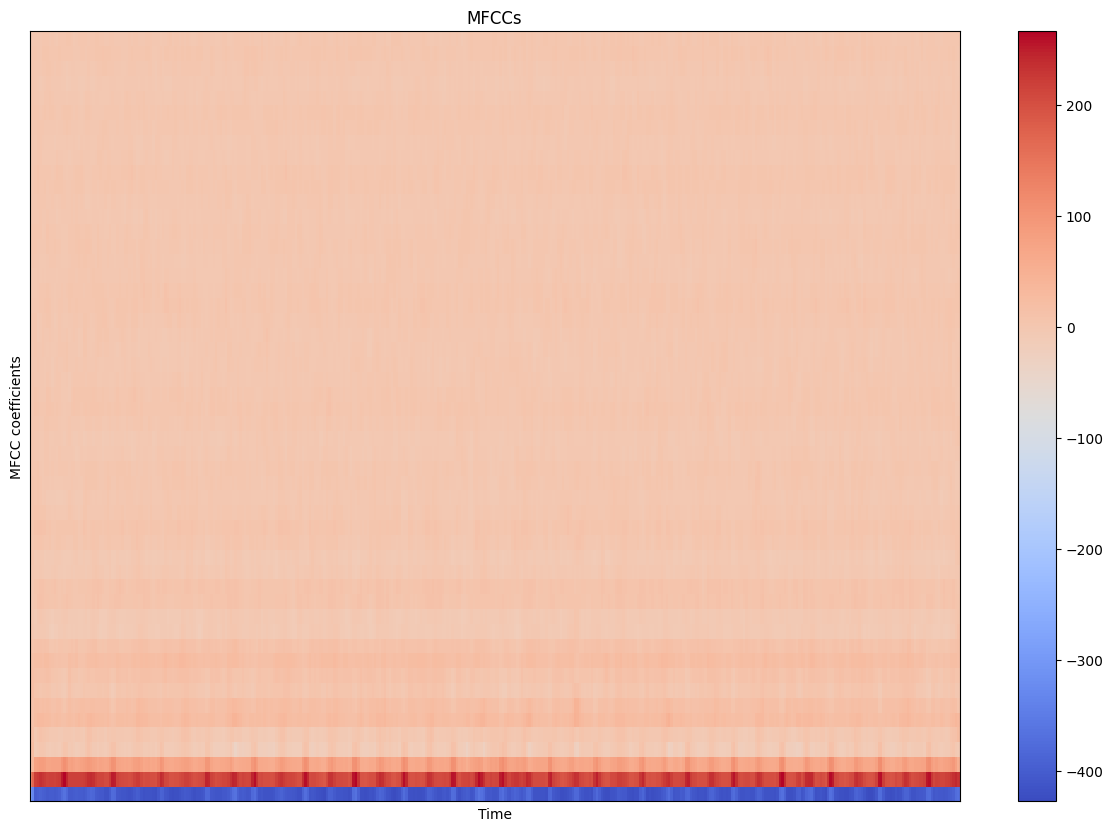

In [18]:
normal_audio, normal_sample  = random_sound(normal_data)
normal_audio
show_audio_waveform(normal_sample)
show_audio_spectrum(normal_sample)
show_spectrogram(normal_sample)
show_mfcc_features(normal_sample)

#### 2. Murmur sound
Heart murmurs sound as though there is a “whooshing, roaring, rumbling, or turbulent fluid” noise in one of two temporal locations: (1) between “lub” and “dub”, or (2) between “dub” and “lub”. They can be a symptom of many heart disorders, some serious.


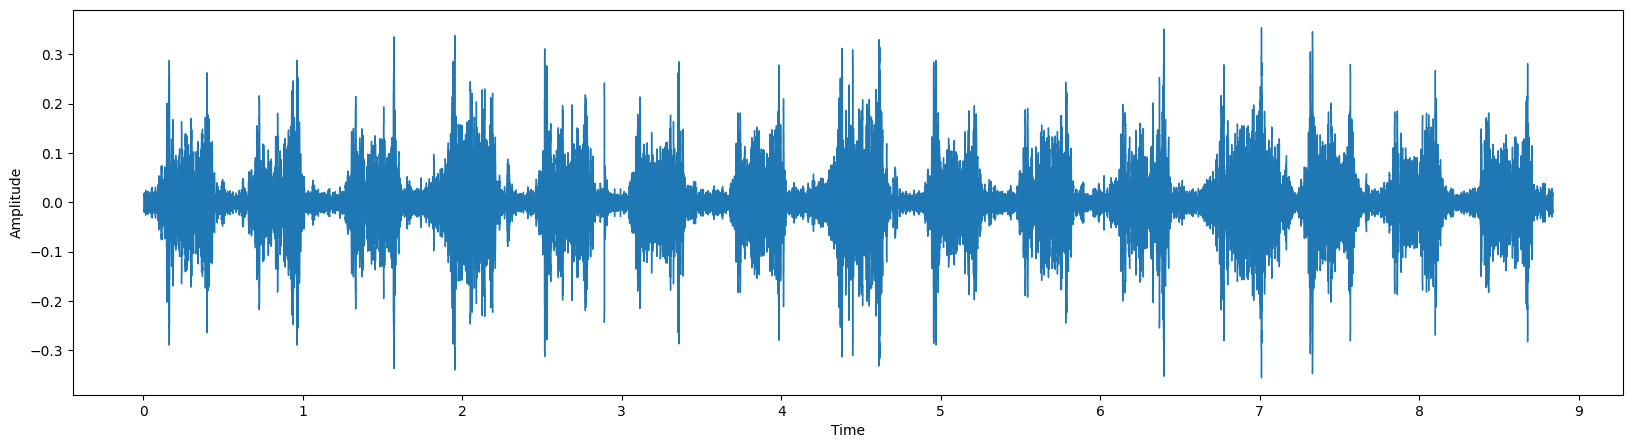

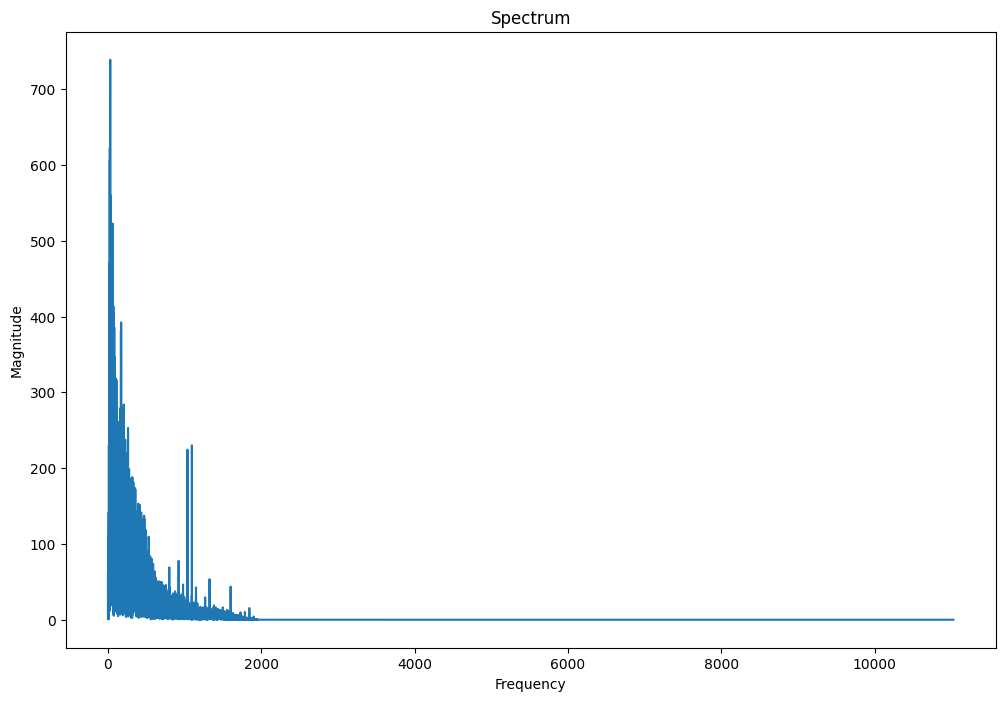

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


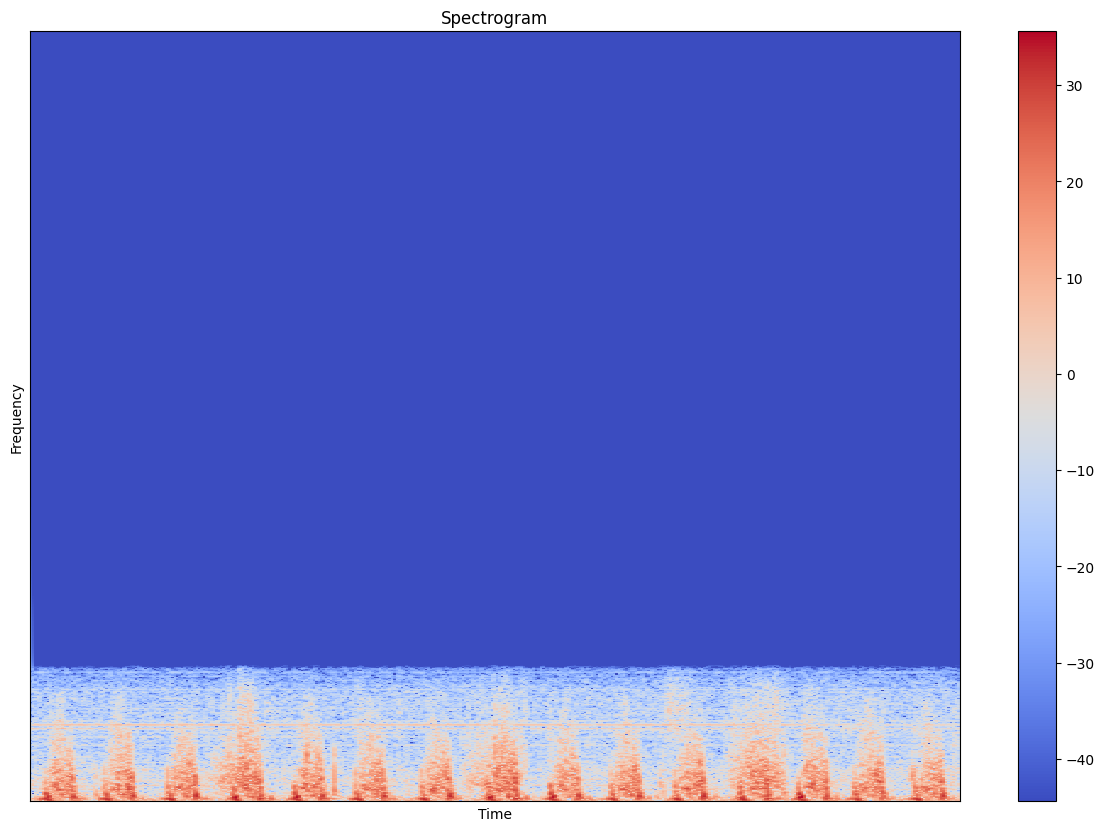

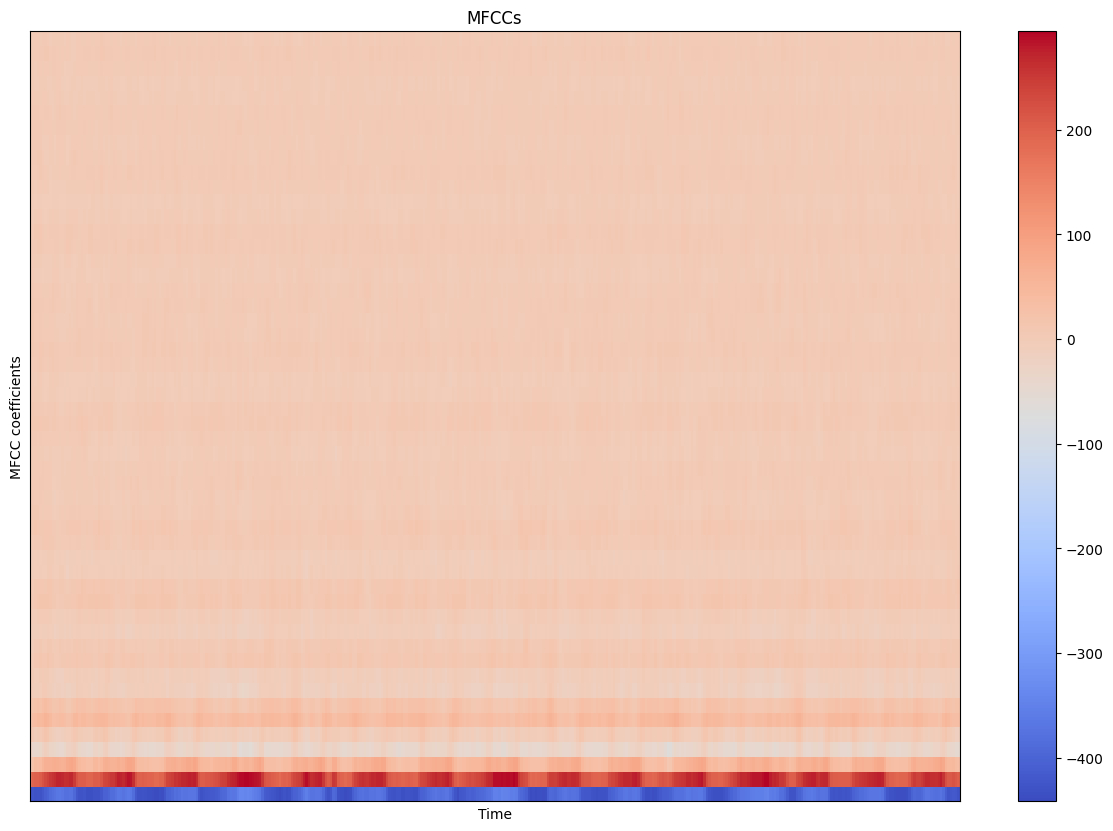

In [19]:

murmur_audio, murmur_sample  = random_sound(murmur_data)
murmur_audio
show_audio_waveform(murmur_sample)
show_audio_spectrum(murmur_sample)
show_spectrogram(murmur_sample)
show_mfcc_features(murmur_sample)

#### 3. Extrastole sound
• Extrasystole sounds may appear occasionally and can be identified because there is a heart sound that is out of rhythm involving extra or skipped heartbeats, e.g. a “lub-lub dub” or a “lub dub-dub


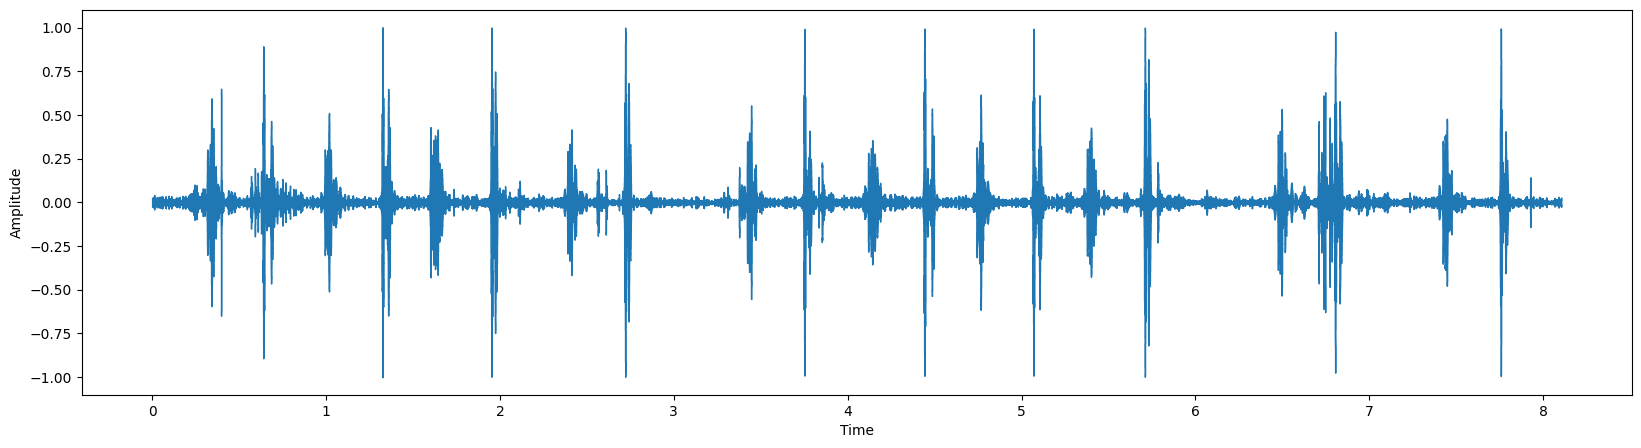

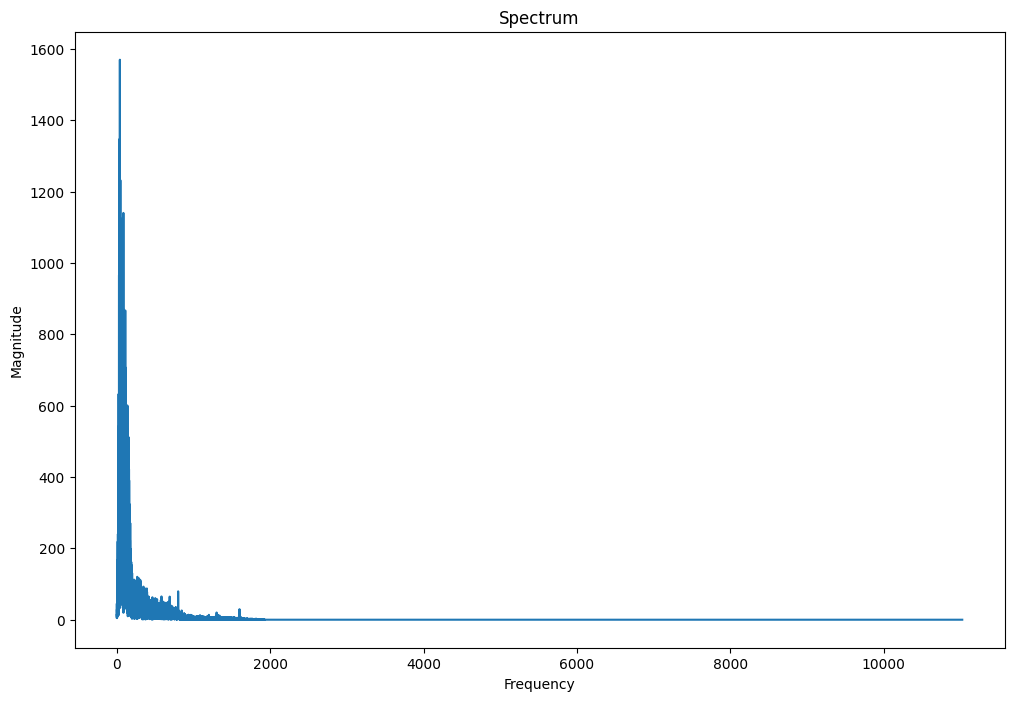

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


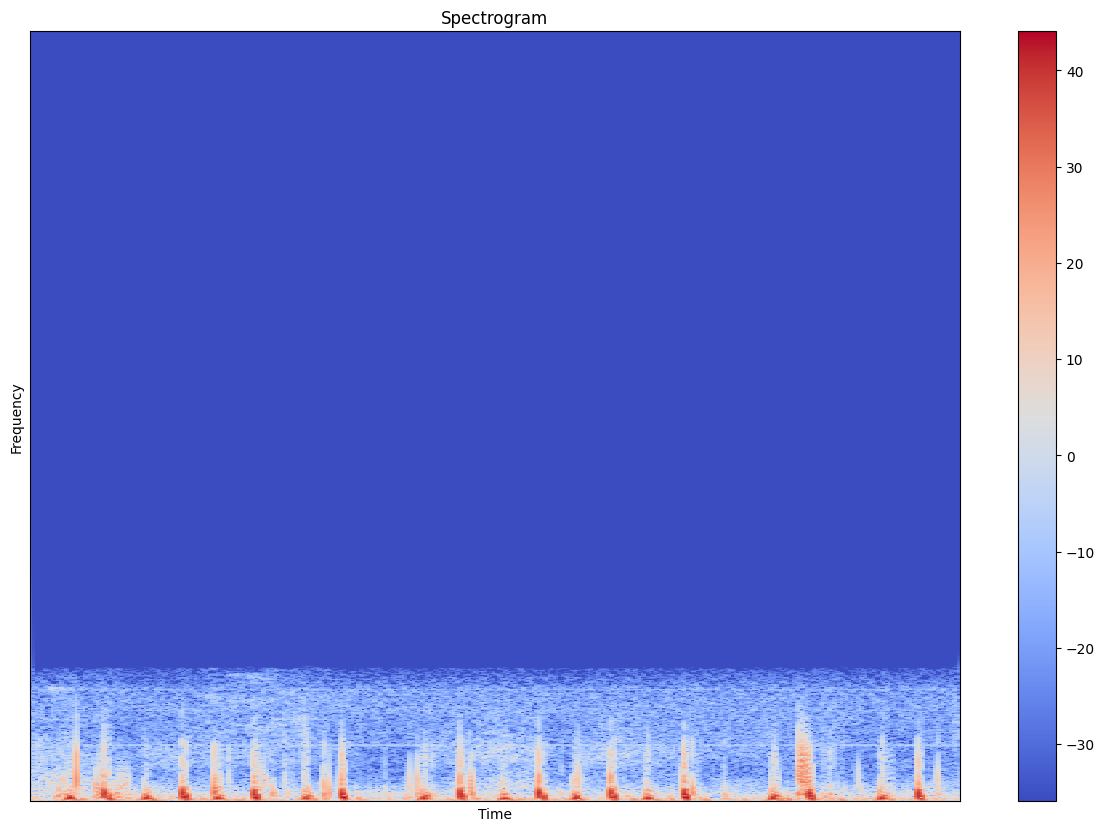

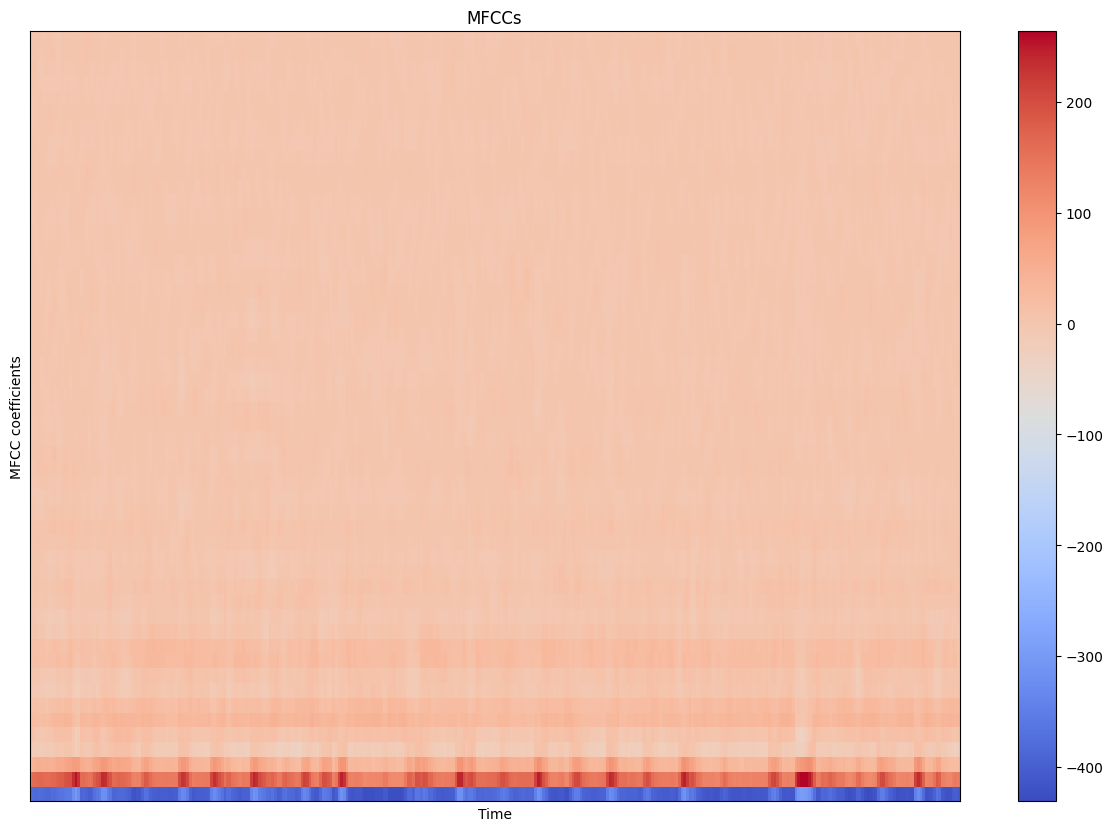

In [20]:

extrastole_audio, extrastole_sample  = random_sound(extrastole_data)
extrastole_audio
show_audio_waveform(extrastole_sample)
show_audio_spectrum(extrastole_sample)
show_spectrogram(extrastole_sample)
show_mfcc_features(extrastole_sample)


#### 4. Artifact sound
• In the Artifact category there are a wide range of different sounds, including feedback squeals and echoes, speech, music and noise.


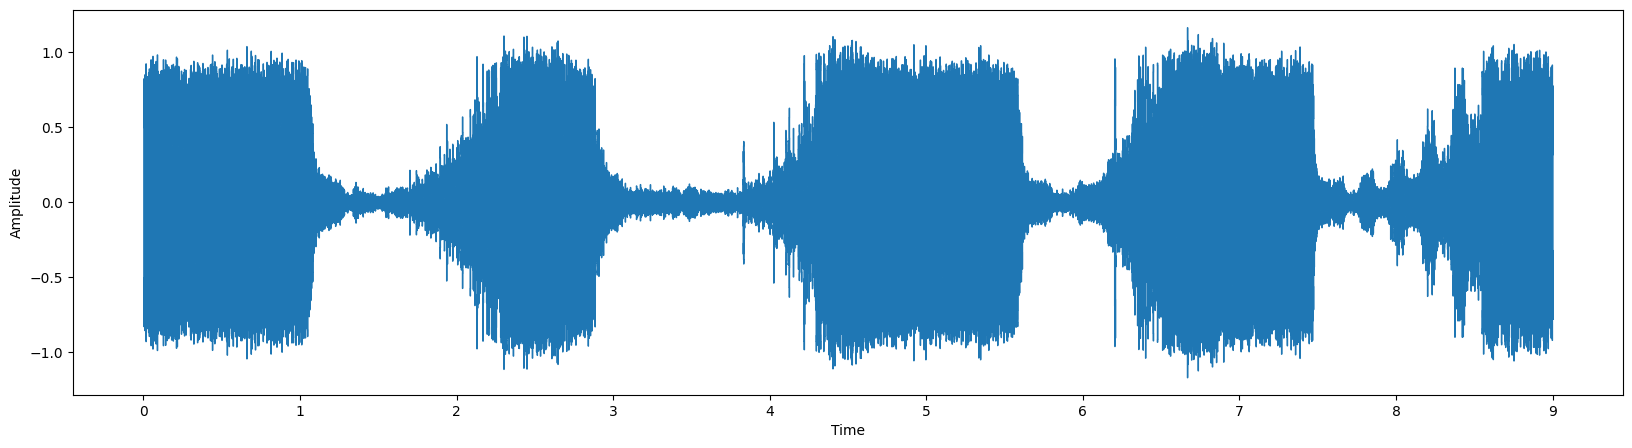

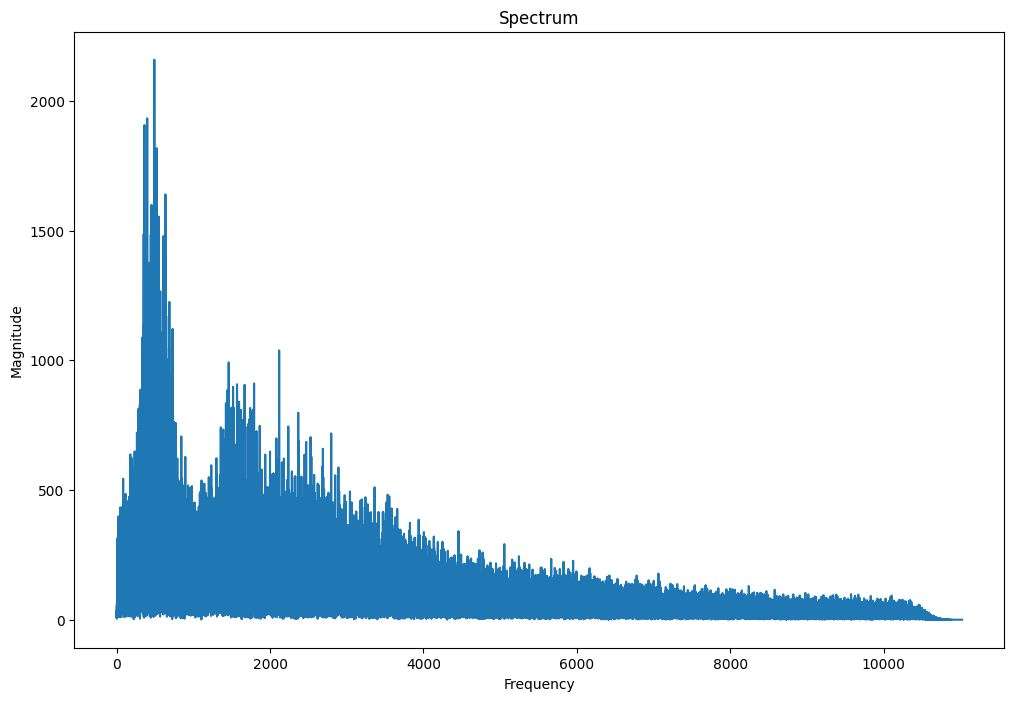

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


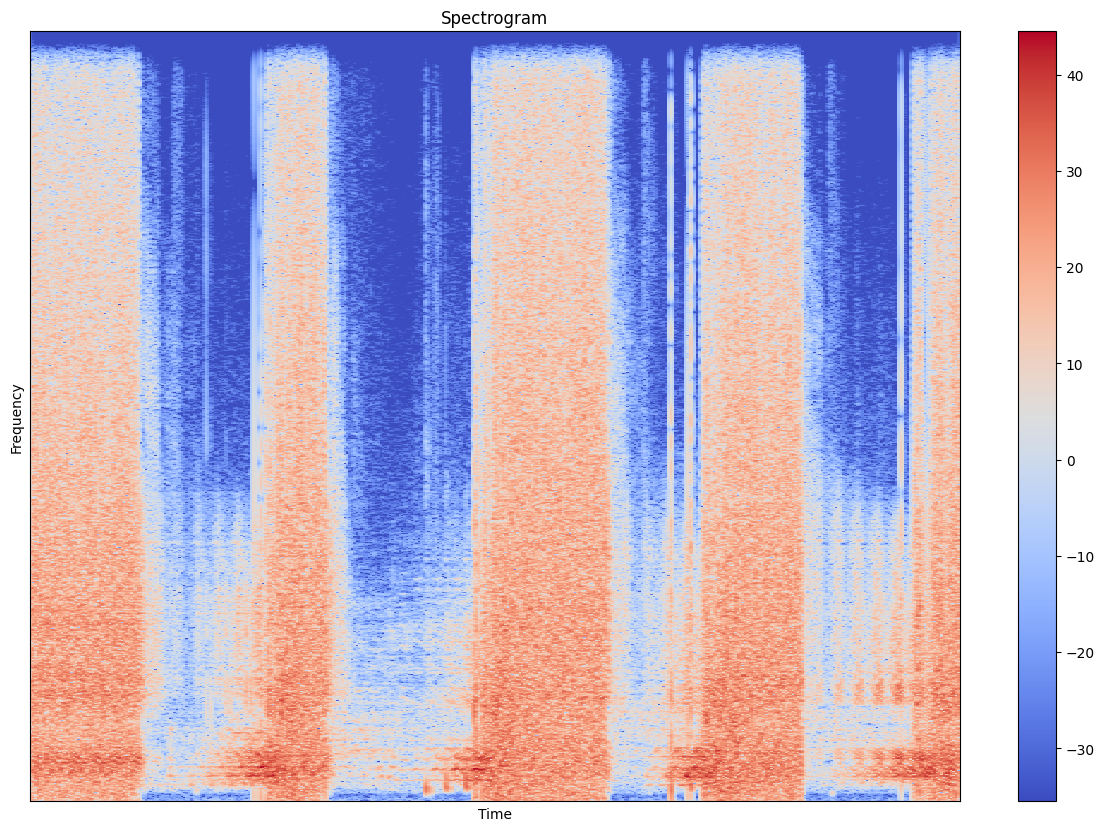

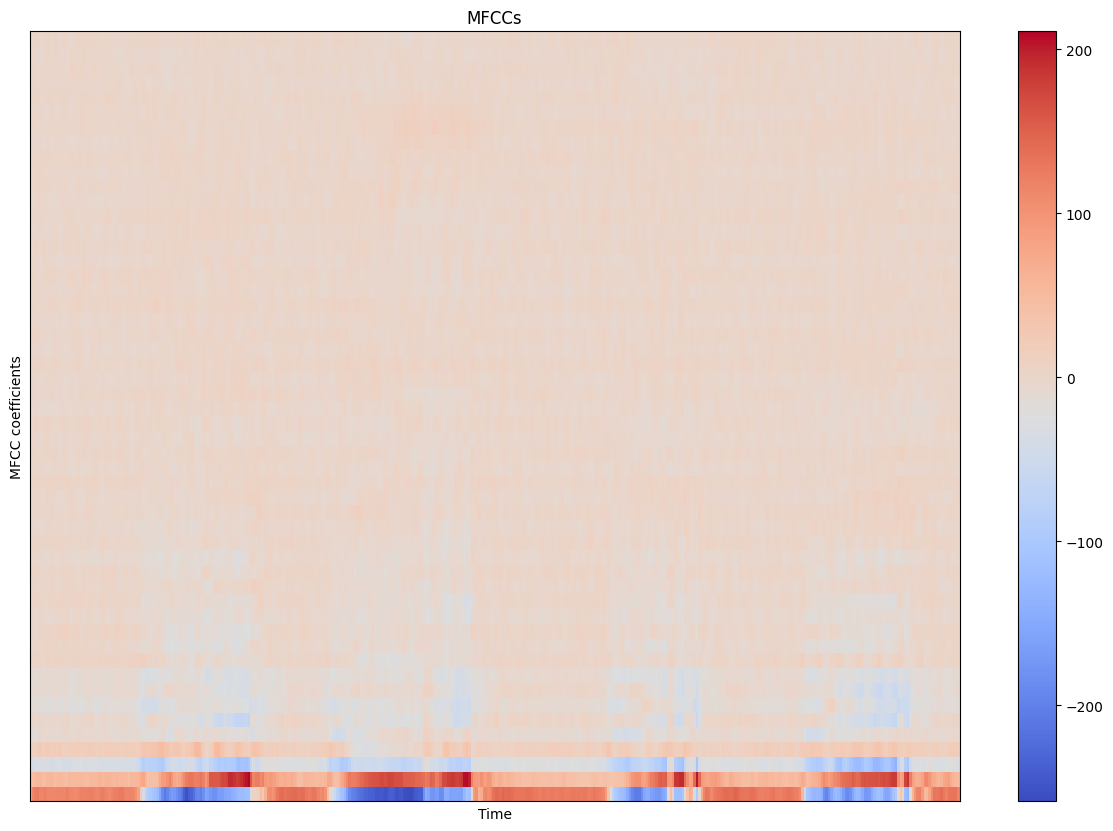

In [21]:
artifact_audio, artifact_sample  = random_sound(artifact_data)
artifact_audio
show_audio_waveform(artifact_sample)
show_audio_spectrum(artifact_sample)
show_spectrogram(artifact_sample)
show_mfcc_features(artifact_sample)


#### 5. Extrahls sound
 Extra heart sounds can be identified because there is an additional sound, e.g. a “lub-lub dub” or a “lub dub-dub”.


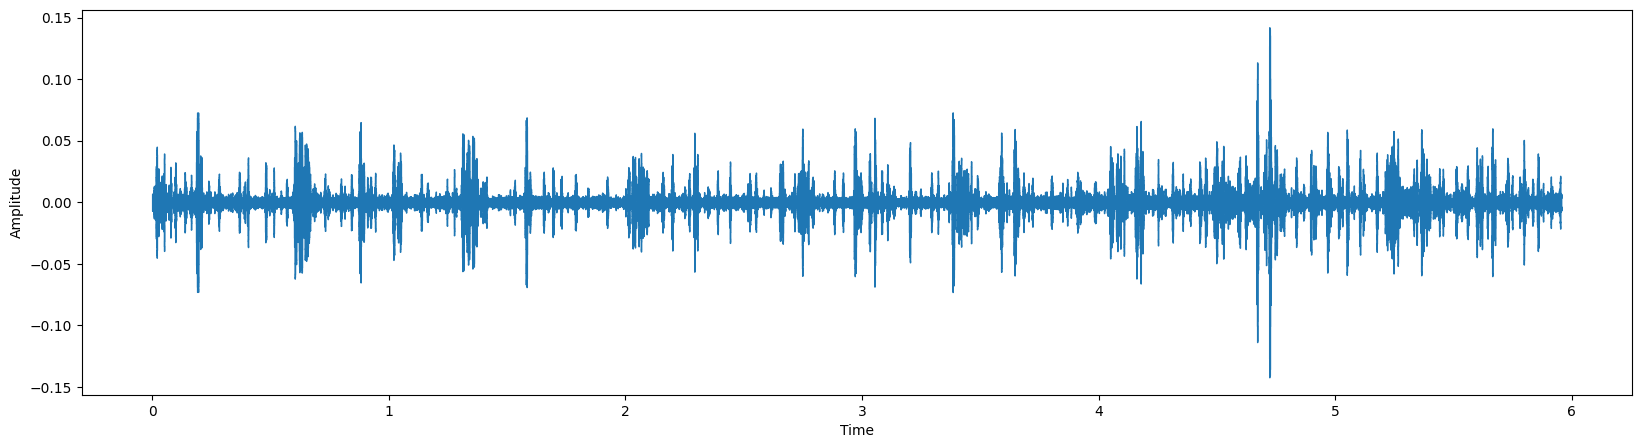

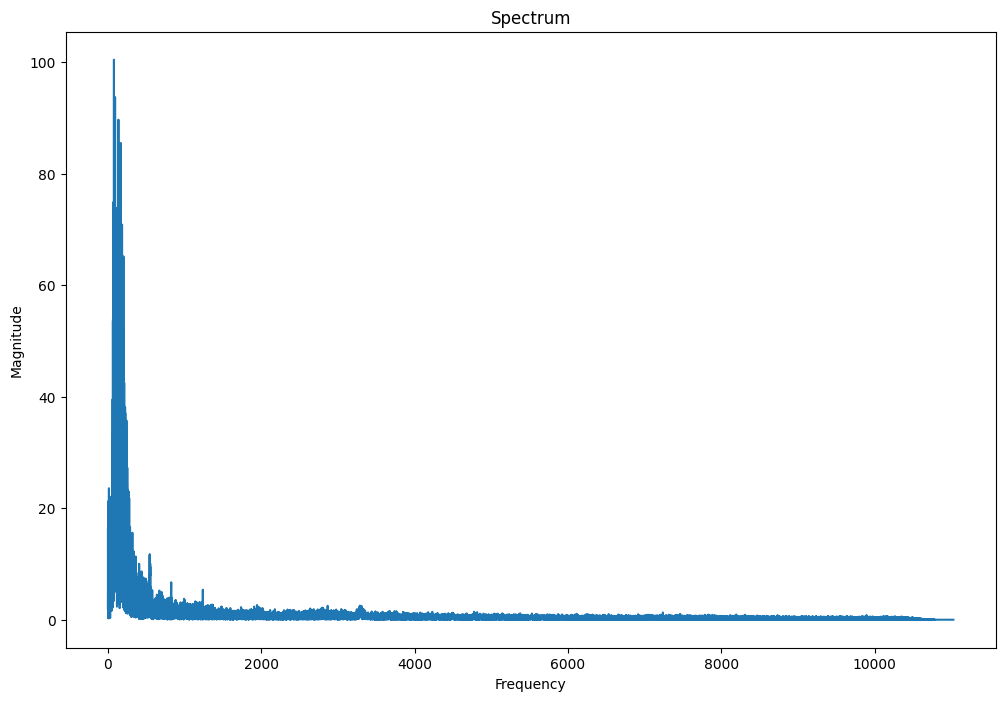

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


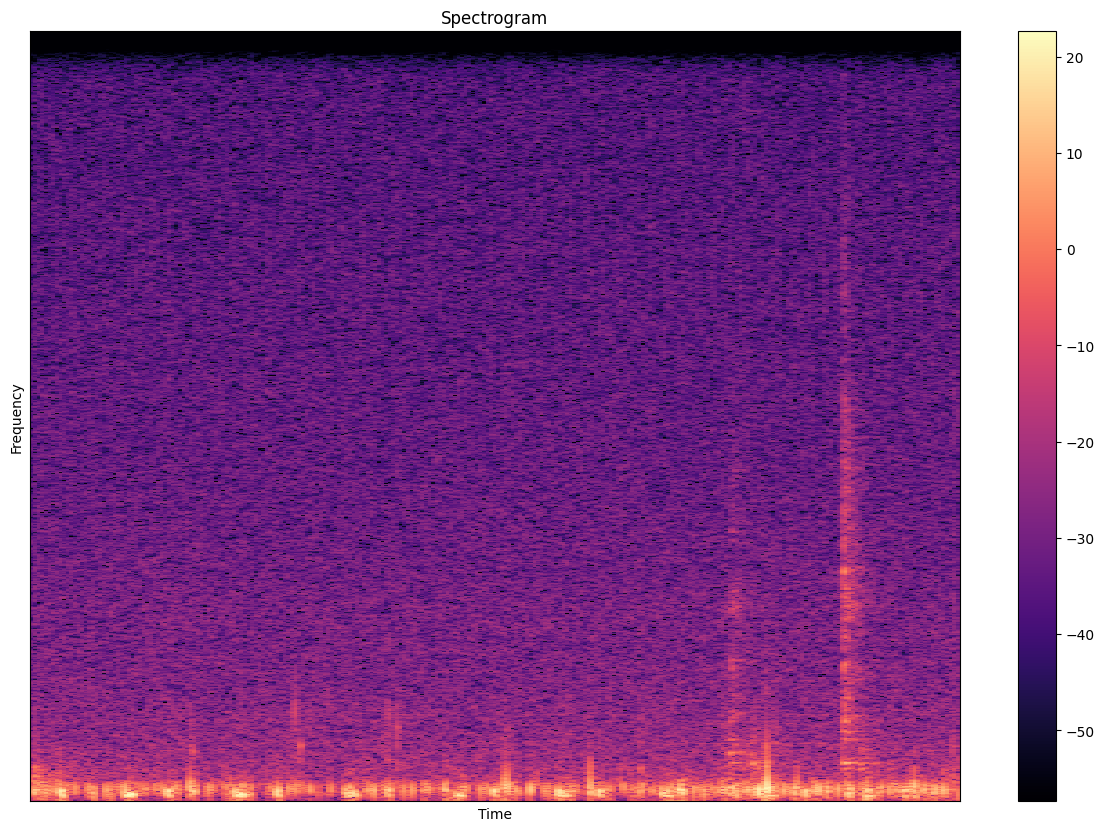

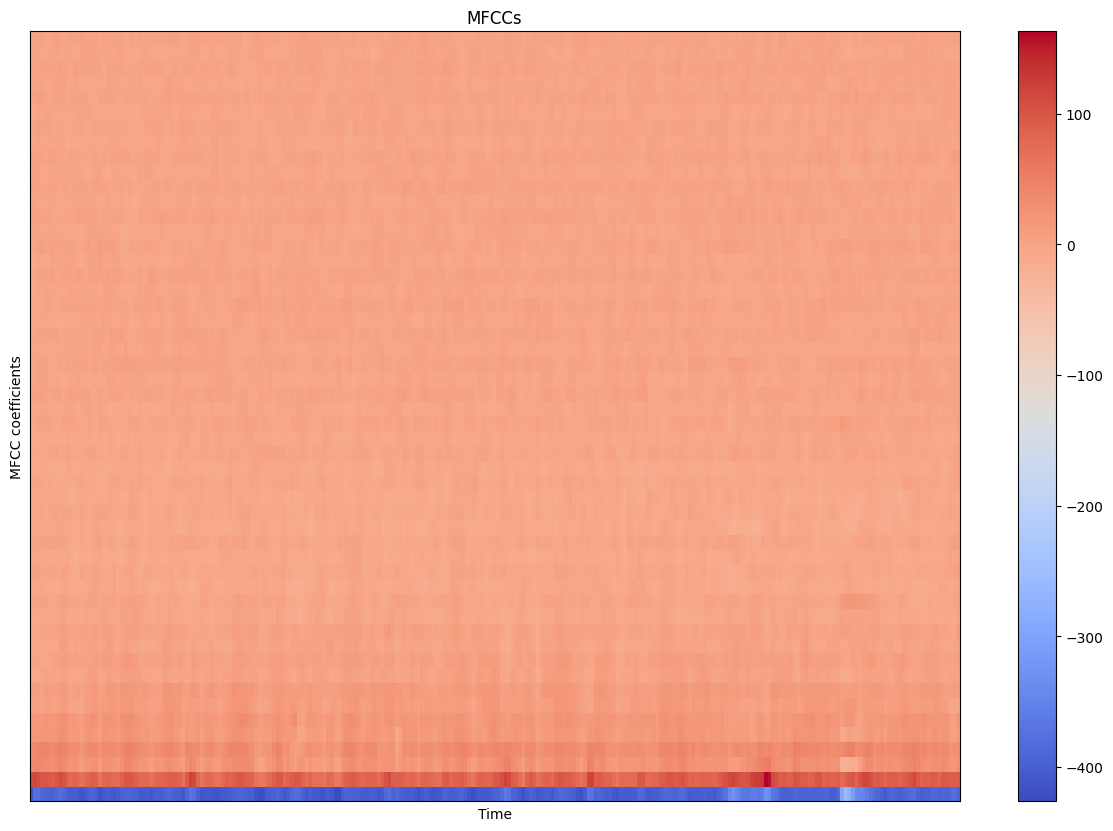

In [22]:
extrahls_audio, extrahls_sample  = random_sound(extrahls_data)
extrahls_audio
show_audio_waveform(extrahls_sample)
show_audio_spectrum(extrahls_sample)
show_spectrogram(extrahls_sample)
show_mfcc_features(extrahls_sample)

In [23]:

## Data Preprocessing
def add_noise(data, x=0.005):
    noise = np.random.randn(len(data))
    return data + x * noise

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch_shift(data, rate=2):
    # Corrected Sample Rate from 220250 to 22050
    return librosa.effects.pitch_shift(y=data, sr=22050, n_steps=rate)
# --- DEBUGGING AND FEATURE EXTRACTION ---


In [24]:
# --- DEBUGGING AND FEATURE EXTRACTION ---

def load_file_data(folder, duration=10, sr=22050):
    input_length = sr * duration
    features = 52
    data = []
    
    # DEBUG: Check if folder exists
    if not os.path.exists(folder):
        print(f"❌ Error: Folder not found at {folder}")
        return data

    # DEBUG: List all files to see extensions
    all_files = os.listdir(folder)
    # This filters for .wav (case-insensitive)
    file_names = [f for f in all_files if f.lower().endswith('.wav')]
    
    print(f"📂 Checking {os.path.basename(folder)}: Found {len(all_files)} total files, {len(file_names)} are .wav")

    for file_name in file_names:
        try:
            file_path = os.path.join(folder, file_name)
            X, _ = librosa.load(file_path, sr=sr, duration=duration)
            
            if len(X) < input_length:
                X = librosa.util.fix_length(X, size=input_length)
            
            # Original + 3 Augmentations
            data.append(np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=features).T, axis=0).reshape([-1,1]))
            data.append(np.mean(librosa.feature.mfcc(y=add_noise(X), sr=sr, n_mfcc=features).T, axis=0).reshape([-1,1]))
            data.append(np.mean(librosa.feature.mfcc(y=stretch(X), sr=sr, n_mfcc=features).T, axis=0).reshape([-1,1]))
            data.append(np.mean(librosa.feature.mfcc(y=pitch_shift(X), sr=sr, n_mfcc=features).T, axis=0).reshape([-1,1]))
            
        except Exception as e:
            pass # Keep going if one file fails
            
    return data



In [25]:

# --- EXECUTION ---
print("--- Starting Debug Load ---")
normal_features     = load_file_data(normal_data)
murmur_features     = load_file_data(murmur_data)
extrastole_features = load_file_data(extrastole_data)
extrahls_features   = load_file_data(extrahls_data)
artifact_features   = load_file_data(artifact_data)


--- Starting Debug Load ---
📂 Checking : Found 351 total files, 351 are .wav
📂 Checking : Found 129 total files, 129 are .wav
📂 Checking : Found 46 total files, 46 are .wav
📂 Checking : Found 19 total files, 19 are .wav
📂 Checking : Found 40 total files, 40 are .wav


In [26]:
# --- FINAL SUMMARY ---
classes = ['normal', 'murmur', 'extrastole', 'extrahls', 'artifact']
feature_lists = [normal_features, murmur_features, extrastole_features, extrahls_features, artifact_features]

print("\n" + "="*40)
print(f"{'CLASS':<15} | {'COUNT':<10}")
print("-" * 40)
for name, f_list in zip(classes, feature_lists):
    print(f"{name.upper():<15} | {len(f_list):<10}")
print("="*40)


CLASS           | COUNT     
----------------------------------------
NORMAL          | 1404      
MURMUR          | 516       
EXTRASTOLE      | 184       
EXTRAHLS        | 76        
ARTIFACT        | 160       


In [27]:

# --- CONSOLIDATE DATA ---
def create_dataset(feature_lists, label_names):
    X = []
    y = []
    
    for i, f_list in enumerate(feature_lists):
        for feature in f_list:
            X.append(feature)
            y.append(i) # Use the index as the numeric label
            
    return np.array(X), np.array(y)




In [28]:
# Convert to arrays
X, y = create_dataset(feature_lists, classes)

# Reshape X for the model: (samples, features, 1) 
# This is required for Conv1D or LSTM layers
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Final X shape: {X.shape}") # Should be (2340, 52, 1)
print(f"Final y shape: {y.shape}")
# One-hot encoding
y_encoded = to_categorical(y, num_classes=len(classes))

Final X shape: (2340, 52, 1)
Final y shape: (2340,)


In [29]:

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1872
Testing samples: 468


In [30]:

# --- 1. DATA SPLITTING (Train, Validation, Test) ---
# First split: 80% for (Training + Validation), 20% for final Testing
x_train_full, x_test_lstm, y_train_full, y_test_lstm = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y)

# Second split: Take the 80% and split it again (80/20) for Train and Val
x_train_lstm, x_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# Now all variables exist and are lowercase:
print(f"✅ Train samples: {x_train_lstm.shape[0]}")
print(f"✅ Val samples:   {x_val_lstm.shape[0]}")
print(f"✅ Test samples:  {x_test_lstm.shape[0]}")

✅ Train samples: 1497
✅ Val samples:   375
✅ Test samples:  468


In [31]:

from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, LSTM

# Ensure the output layer matches with 5 classes
lstm_model = Sequential()
lstm_model.add(Conv1D(1024, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(52, 1)))
lstm_model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
lstm_model.add(BatchNormalization())

lstm_model.add(Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'))
lstm_model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
lstm_model.add(BatchNormalization())

lstm_model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
lstm_model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
lstm_model.add(BatchNormalization())

lstm_model.add(LSTM(128, return_sequences=True))
lstm_model.add(LSTM(128))

lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(len(classes), activation='softmax')) # Changed 3 to 5

lstm_model.summary()

c:\Users\tooba\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 52, 1024)       │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 512)        │     2,621,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 256)        │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,630,085 (13.85 MB)

 Trainable params: 3,626,501 (13.83 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [32]:
# 1. compile 
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [33]:

# --- 2. TRAINING ---
checkpoint = ModelCheckpoint(
    'heartbeat_classifier.h5', 
    monitor='val_accuracy', 
    save_best_only=True,
     mode='max')

     
early_stop = EarlyStopping(
    monitor='val_loss',
     patience=10, 
     restore_best_weights=True)


In [ ]:


print("\n🚀 Training Model...")
history = lstm_model.fit(
    x_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(x_val_lstm, y_val_lstm),
    callbacks=[checkpoint, early_stop],
    verbose=1
)


🚀 Training Model...
Epoch 1/50
42/47 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5330 - loss: 1.3245

In [ ]:

# --- 3. SAVE FINAL MODEL ---
lstm_model.save('final_heartbeat_model.h5')
print("✅ Model saved as final_heartbeat_model.h5")

In [ ]:
# --- 4. VISUALIZE TRAINING HISTORY ---
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [ ]:


# --- 5. EVALUATION ON TEST SET ---
test_loss, test_acc = lstm_model.evaluate(x_test_lstm, y_test_lstm, verbose=0)
print(f"\n🔥 Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

In [ ]:

# --- 6. CONFUSION MATRIX & CLASSIFICATION REPORT ---
y_pred = lstm_model.predict(x_test_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_lstm, axis=1)
from sklearn.metrics import classification_report, confusion_matrix
# Classification Report
print("\n📝 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()